<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Controls/E_20_222_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

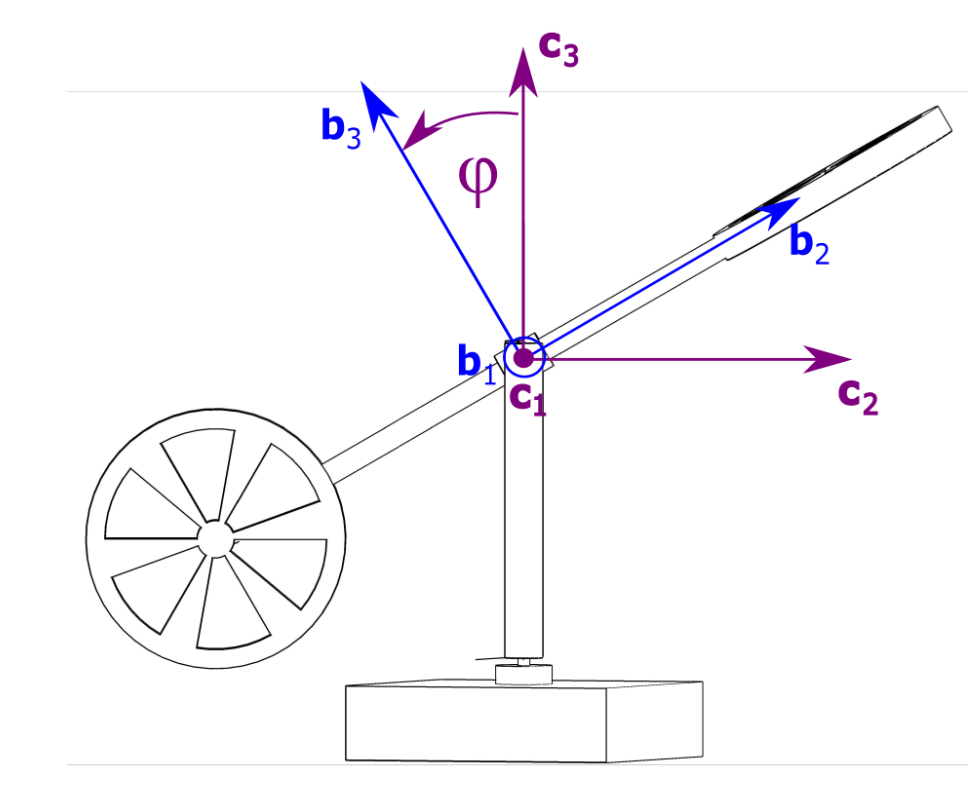

 ## Task 1 — Dynamic Model of the Twin Rotor System


# 1. Configuration Space

The twin–rotor mechanism performs rotational motion about a fixed pivot point.
Therefore the configuration of the system belongs to the Lie group

$$R(t) \in SO(3)$$

To describe the orientation, two rotations are used:

1. A rotation of angle $\theta$ about the inertial axis $e_3$
2. A rotation of angle $\phi$ about the intermediate body axis $b_1$

Hence the overall rotation matrix can be written as

$$R = R_1(\phi) R_3(\theta)$$

where

$$R_1(\phi) =
\begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}$$

and

$$R_3(\theta) =
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1
\end{bmatrix}$$

---

# 2. Angular Velocity and Kinematics on $SO(3)$

For a rigid body whose orientation evolves on the manifold $SO(3)$, the kinematic relation is

$$\dot{R} = R \hat{\Omega}$$

where $\Omega$ denotes the angular velocity expressed in body coordinates and

$$\hat{\Omega} =
\begin{bmatrix}
0 & -\Omega_3 & \Omega_2 \\
\Omega_3 & 0 & -\Omega_1 \\
-\Omega_2 & \Omega_1 & 0
\end{bmatrix}$$

From the chosen rotation sequence, the body angular velocity becomes

$$\Omega =
\begin{bmatrix}
\dot{\phi} \\
\dot{\theta}\sin\phi \\
\dot{\theta}\cos\phi
\end{bmatrix}$$

The spatial angular velocity is related to the body velocity through

$$\omega = R\Omega$$

Therefore the kinematic equation may also be written as

$$\dot{R} = \hat{\omega}R$$

---

# 3. Inertia and Angular Momentum

Assume that the inertia tensor of the body is diagonal:

$$I =
\begin{bmatrix}
I_1 & 0 & 0 \\
0 & I_2 & 0 \\
0 & 0 & I_3
\end{bmatrix}$$

The angular momentum expressed in spatial coordinates is

$$\pi = R I \Omega$$

Since the relation between spatial and body angular velocity is

$$\Omega = R^T \omega$$

the momentum can also be expressed as

$$\pi = R I R^T \omega$$

Consequently the angular velocity can be recovered from the momentum by

$$\omega = (R I R^T)^{-1}\pi$$

---

# 4. Rotational Dynamics

The rotational motion of the rigid body in spatial form is governed by

$$\dot{\pi} = \tau$$

where $\tau$ represents the total torque applied to the system.

This torque can be separated into two components

$$\tau = \tau^e + \tau^u$$

where

- $\tau^u$ represents the controllable torque produced by the rotors
- $\tau^e$ represents constraint forces imposed by the mechanical structure

Thus the momentum evolution equation becomes

$$\dot{\pi} = \tau^e + \tau^u$$

---

# 5. Control Torque

The thrust generated by the two rotors creates moments acting within the $b_1$–$b_3$ plane.

The control torque expressed in spatial coordinates can be written as

$$\tau^u =
R
\begin{bmatrix}
u_1\cos\alpha - u_2\cos\beta \\
0 \\
u_1\sin\alpha - u_2\sin\beta
\end{bmatrix}$$

This torque has no component along the $b_2$ axis.

---

# 6. Constraint Torque

The system design restricts rotation around the $b_2$ direction.
To enforce this restriction, a constraint torque must appear along that axis.

The Euler equation for the rigid body in body coordinates is

$$I\dot{\Omega} + \Omega \times (I\Omega) = T$$

where $T$ denotes the torque in body coordinates.

Projecting this equation onto the $e_2$ direction gives

$$T_2 =
e_2^T(\Omega \times I\Omega + I\dot{\Omega})$$

Therefore the constraint torque expressed in spatial coordinates becomes

$$\tau^e =
R
\begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix}$$

---

# 7. Final Dynamic Model

Combining the kinematic and dynamic relationships, the twin rotor system can be summarized by the following equations.

**Kinematics:**

$$\dot{R} = \hat{\omega}R$$

**Momentum dynamics:**

$$\dot{\pi} = \tau^e + \tau^u$$

**Velocity–momentum relation:**

$$\omega = (RIR^T)^{-1}\pi$$

**Control torque:**

$$\tau^u =
R
\begin{bmatrix}
u_1\cos\alpha - u_2\cos\beta \\
0 \\
u_1\sin\alpha - u_2\sin\beta
\end{bmatrix}$$

**Constraint torque:**

$$\tau^e =
R
\begin{bmatrix}
0 \\
e_2^T(\Omega \times I\Omega + I\dot{\Omega}) \\
0
\end{bmatrix}$$

This formulation provides a geometric representation of the twin–rotor dynamics on the Lie group $SO(3)$.

**Relation Between $\Omega$ and $\omega$:**

$$\Omega = R^T \omega$$

## Task 2: Simulation of the Motion of the Twin Rotor System

In the body-fixed frame $\mathbf{b}$, the principal moments of inertia $I_1$, $I_2$, and $I_3$
correspond to rotations about the pitch, roll, and yaw axes, respectively.
Since the mechanical design of the experimental setup prevents rolling motion,
the inertia component $I_2$ has no effect on the dynamics and is therefore neglected.
Furthermore, the moment of inertia about the yaw axis exceeds that about the pitch axis,
satisfying $I_3 > I_1$. This inequality arises from the fact that yaw rotation involves
heavier structural elements — including the vertical support column — while pitch rotation
is governed primarily by the horizontal arm that connects the two rotor assemblies.

In [3]:
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp

# ── Inertia tensor ──────────────────────────────────────────────
I1, I2, I3 = 1.0, 2.0, 1.5
I = np.diag([I1, I2, I3])

# ── Control input selector ──────────────────────────────────────
CASE = 4   # change to 1, 2, 3, or 4

def control_inputs(t):
    cases = {
        1: [0.5 * np.sin(2 * t), -0.2 * np.cos(t)],
        2: [1.0, 1.0],
        3: [1.0, 0.0],
        4: [0.0, 1.0],
    }
    return np.array(cases[CASE])

# ── Individual accessors ─────────────────────────────────────────
u1 = lambda t: control_inputs(t)[0]
u2 = lambda t: control_inputs(t)[1]

## Twin Rotor System — Dynamic Model Derivation

Working in the body-fixed frame, the following quantities are introduced:

$$
T_e =
\begin{bmatrix}
0 \\
T_{e_2} \\
0
\end{bmatrix}, \quad
\Omega =
\begin{bmatrix}
\Omega_1 \\
\Omega_2 \\
\Omega_3
\end{bmatrix}, \quad
I =
\begin{bmatrix}
I_1 & 0 & 0 \\
0 & I_2 & 0 \\
0 & 0 & I_3
\end{bmatrix}
$$

Applying Euler's rigid body equation yields the governing rotational dynamics:

$$
T_e + T_u = \Omega \times (I \Omega) + I \dot{\Omega}
$$

Substituting the explicit forms of the constraint and control torque vectors:

$$
\begin{bmatrix}
0 \\
T_{e_2} \\
0
\end{bmatrix}
+
\begin{bmatrix}
u_1 \\
0 \\
-u_2
\end{bmatrix}
=
\begin{bmatrix}
(I_3 - I_2)\Omega_2 \Omega_3 + I_1 \dot{\Omega}_1 \\
(I_1 - I_3)\Omega_1 \Omega_3 + I_2 \dot{\Omega}_2 \\
(I_2 - I_1)\Omega_1 \Omega_2 + I_3 \dot{\Omega}_3
\end{bmatrix}
$$

---

### Body Angular Velocity in Generalized Coordinates

Expressing the body angular velocity vector in terms of the generalized coordinates $\phi$ and $\theta$:

$$
\Omega =
\begin{bmatrix}
\dot{\phi} \\
\dot{\theta} \sin\phi \\
\dot{\theta} \cos\phi
\end{bmatrix}
$$

Differentiating with respect to time:

$$
\dot{\Omega} =
\begin{bmatrix}
\ddot{\phi} \\
\ddot{\theta} \sin\phi + \dot{\theta}\dot{\phi}\cos\phi \\
\ddot{\theta} \cos\phi - \dot{\theta}\dot{\phi}\sin\phi
\end{bmatrix}
$$

---

### Row-wise Expansion of the Euler Equation

Matching each row on both sides of the Euler equation gives three scalar relations:

$$
u_1 = (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi + I_1 \ddot{\phi}
$$

$$
T_{e_2} = (I_1 - I_3)\dot{\phi}\dot{\theta}\cos\phi + I_2\left(\ddot{\theta}\sin\phi + \dot{\theta}\dot{\phi}\cos\phi\right)
$$

$$
-u_2 = (I_2 - I_1)\dot{\phi}\dot{\theta}\sin\phi + I_3\left(\ddot{\theta}\cos\phi - \dot{\theta}\dot{\phi}\sin\phi\right)
$$

The quantity $T_{e_2}$ captures the reaction torque acting at the pivot joint.

---

### Solved Equations of Motion

Rearranging the first and third scalar equations for the second-order derivatives:

$$
\ddot{\phi} =
\frac{1}{I_1}
\left[
u_1 - (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi
\right]
$$

$$
\ddot{\theta} =
\frac{1}{\cos\phi}
\left[
\frac{1}{I_3}
\left(
(I_1 - I_2)\dot{\phi}\dot{\theta}\sin\phi - u_2
\right)
+ \dot{\theta}\dot{\phi}\sin\phi
\right]
$$

---

### Kinematic Singularity

The equations of motion lose validity when:

$$
\phi = 90°
$$

At this configuration, $\cos\phi = 0$ causes the expression for $\ddot{\theta}$ to become undefined.
This breakdown is a kinematic singularity, commonly referred to as **gimbal lock**.

In [4]:
# ══════════════════════════════════════════════════════════════
#  Twin Rotor — Dynamics · Simulation · 3-D Animation
# ══════════════════════════════════════════════════════════════

# ─── Parameters ───────────────────────────────────────────────
L_VERT   = 2.0          # vertical support length
L_BEAM   = 3.0          # horizontal beam length
EPS      = 1e-5         # singularity guard threshold
T_SPAN   = (0, 10)
N_PTS    = 300
IC       = [0.1, 0.0, 0.0, 0.0]   # θ, φ, θ̇, φ̇


# ─── 1  Equations of motion ───────────────────────────────────

def twin_rotor_ode(t, state):
    th, ph, th_d, ph_d = state

    cp = np.cos(ph)
    cp = max(cp,  EPS) if cp >= 0 else min(cp, -EPS)   # avoid ÷0

    ddph = (u1(t) - (I3 - I2) * th_d**2 * np.sin(ph) * cp) / I1
    ddth = (-u2(t) - (I2 - I1 - I3) * th_d * ph_d * np.sin(ph)) / (I3 * cp)

    return [th_d, ph_d, ddth, ddph]


# ─── 2  Integrate ─────────────────────────────────────────────

t_eval   = np.linspace(*T_SPAN, N_PTS)
result   = solve_ivp(twin_rotor_ode, T_SPAN, IC, t_eval=t_eval)
TH, PH   = result.y[0], result.y[1]


# ─── 3  Rotation matrix  R = Rz(θ) · Rx(φ) ───────────────────

def rotation_matrix(theta, phi):
    c1, s1 = np.cos(theta), np.sin(theta)
    c2, s2 = np.cos(phi),   np.sin(phi)

    Rz = np.array([[c1, -s1, 0],
                   [s1,  c1, 0],
                   [ 0,   0, 1]])

    Rx = np.array([[1,  0,   0],
                   [0, c2, -s2],
                   [0, s2,  c2]])
    return Rz @ Rx


# ─── 4  Geometry for one frame ────────────────────────────────

def make_segments(R):
    """
    Returns flat (x, y, z) lists for Scatter3d.
    Segments are separated by None  →  plotly draws them as
    disconnected line pieces.
    """
    half = L_BEAM / 2

    # local-frame point pairs  (2 × 3)
    parts = {
        "support" : np.array([[0, 0,  0   ], [0, 0, -L_VERT]]),   # fixed
        "beam"    : np.array([[0, -half, 0 ], [0,  half, 0  ]]),
        "rotor1"  : np.array([[ 0.5, -half, 0], [-0.5, -half, 0]]),
        "rotor2"  : np.array([[0,  half,  0.5], [ 0,   half, -0.5]]),
    }

    xs, ys, zs = [], [], []
    for name, pts in parts.items():
        rotated = pts if name == "support" else (R @ pts.T).T
        xs += [rotated[0, 0], rotated[1, 0], None]
        ys += [rotated[0, 1], rotated[1, 1], None]
        zs += [rotated[0, 2], rotated[1, 2], None]

    return xs[:-1], ys[:-1], zs[:-1]   # trim trailing None


# ─── 5  Build animation frames ────────────────────────────────

anim_frames = [
    go.Frame(data=[go.Scatter3d(**dict(zip(["x","y","z"], make_segments(rotation_matrix(th, ph)))))])
    for th, ph in zip(TH, PH)
]

# shorthand for the initial trace
x0, y0, z0 = (anim_frames[0].data[0].x,
               anim_frames[0].data[0].y,
               anim_frames[0].data[0].z)


# ─── 6  Assemble figure ────────────────────────────────────────

shared_axis = dict(range=[-3, 3])

fig = go.Figure(
    data=[go.Scatter3d(x=x0, y=y0, z=z0,
                       mode="lines", line=dict(width=6))],
    frames=anim_frames,
    layout=go.Layout(
        title="Twin Rotor Simulation",
        scene=dict(xaxis=shared_axis,
                   yaxis=shared_axis,
                   zaxis=shared_axis,
                   aspectmode="cube"),
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(
                label="Play",
                method="animate",
                args=[None, dict(frame=dict(duration=20, redraw=True),
                                 fromcurrent=True)]
            )]
        )]
    )
)

fig.show()

## Task 3: PID Control for Trajectory Tracking via Error Dynamics

### Reference Trajectory and Control Objective

Let $(o_r, R_r) \in SE(3)$ denote the desired pose assigned to the twin rotor system.
Since the center of mass coincides with the pivot point, the system undergoes no translational
displacement, which means:

$$o_r \equiv o$$

Consequently, the tracking problem reduces entirely to the rotational component,
requiring only that $R \in SO(3)$ follows the prescribed reference.

---

### Attitude Error on $SO(3)$

To drive the system toward a smooth reference trajectory $R_r(t)$, an error rotation
matrix $R_e \in SO(3)$ is constructed. Depending on which coordinate frame is chosen
for expressing the error, two standard definitions arise:

---

#### 1. Left-Invariant Error — Body Frame

When the error is measured relative to the moving body frame, the compatibility
condition takes the form:

$$R \, R_e = R_r$$

Solving for the error matrix:

$$R_e = R^T R_r$$

---

#### 2. Right-Invariant Error — Inertial Frame

When the error is instead expressed in the fixed inertial frame, the condition becomes:

$$R_e \, R = R_r$$

which yields:

$$R_e = R_r R^T$$

---

Because the dynamic model of the twin rotor system is formulated with respect to the
inertial (earth-fixed) frame, the **right-invariant error** definition is adopted
throughout the remainder of the analysis and controller synthesis.

### Part I: Derivation of Tracking Error Dynamics

#### Reference Angular Velocity

Let $\omega_r$ denote the spatial angular velocity of the reference trajectory.
It is extracted from the reference rotation via the skew-symmetric map:

$$\widehat{\omega}_r = \dot{R}_r R_r^T$$

---

#### Velocity Error Construction

The angular velocity error is introduced through its skew-symmetric representative:

$$\widehat{\omega}_e \triangleq \dot{R}_e R_e^T$$

Starting from $R_e = R_r R^T$ and applying the product rule:

$$\dot{R}_e = \dot{R}_r R^T + R_r \dot{R}^T$$

Inserting this into the error definition:

$$\widehat{\omega}_e = (\dot{R}_r R^T + R_r \dot{R}^T)\, R_e^T$$

Redistributing the factors:

$$\widehat{\omega}_e = \dot{R}_r (R^T R_e^T) + (R_r R)\dot{R}^T R_e^T$$

Invoking $R_e = R_r R^T$ to simplify:

$$\widehat{\omega}_e = \dot{R}_r R_r^T + R_e (R \dot{R}^T) R_e^T$$

The orthogonality condition $RR^T = I$ implies $R\dot{R}^T = -\dot{R}R^T$, so:

$$\widehat{\omega}_e = \widehat{\omega}_r - R_e\, \widehat{\omega}\, R_e^T$$

Converting from matrix to vector form yields:

$$\omega_e = \omega_r - R_e\,\omega$$

---

#### Momentum Error Construction

The reference spatial angular momentum is defined as:

$$\pi_r = R_r I R_r^T\,\omega_r$$

A compatible momentum error is then introduced as:

$$\pi_e = R I R_r^T\,\omega_e$$

Substituting the velocity error $\omega_e = \omega_r - R_e\,\omega$:

$$\pi_e = R I R_r^T(\omega_r - R_e\,\omega)$$

After expansion this simplifies to:

$$\pi_e = R_e^T \pi_r - \pi$$

---

#### Evolution of the Momentum Error

Differentiating $\pi_e$ with respect to time:

$$\dot{\pi}_e = \dot{R}_e^T \pi_r + R_e^T \dot{\pi}_r - \dot{\pi}$$

The identity $\dot{R}_e^T = -\widehat{\omega}_e R_e^T$ transforms the first term:

$$\dot{\pi}_e = R_e^T(\dot{\pi}_r - \omega_e \times \pi_r) - \dot{\pi}$$

Writing $\pi_r = R_r \Pi_r$ and differentiating:

$$\dot{\pi}_r = \dot{R}_r \Pi_r + R_r \dot{\Pi}_r$$

Substituting back:

$$\dot{\pi}_e = R_e^T\!\left(\dot{R}_r \Pi_r + R_r \dot{\Pi}_r - \omega_e \times \pi_r\right) - \dot{\pi}$$

Replacing $\dot{R}_r = \widehat{\omega}_r R_r$:

$$\dot{\pi}_e = R_e^T\!\left(R_r \dot{\Pi}_r + \widehat{\omega}_r \pi_r - \omega_e \times \pi_r\right) - \dot{\pi}$$

Grouping the last two terms using $\omega_r - \omega_e = R_e\,\omega$:

$$\dot{\pi}_e = R_e^T\!\left(R_r \dot{\Pi}_r + (\omega_r - \omega_e) \times \pi_r\right) - \dot{\pi}$$

$$\dot{\pi}_e = R_e^T\!\left(R_r \dot{\Pi}_r + R_e\,\omega \times \pi_r\right) - \dot{\pi}$$

Carrying $R_e^T$ through gives the final compact form:

$$\dot{\pi}_e = R\dot{\Pi}_r + \omega \times (R_e^T \pi_r) - \dot{\pi}$$

---

#### Summary — Closed-Form Error Dynamics

$$\dot{R}_e = \widehat{\omega}_e\, R_e$$

$$\dot{\pi}_e =
\Bigl(R\dot{\Pi}_r + \omega \times R_e^T \pi_r\Bigr)
- \tau_u - \tau_e$$

### Part II: Stability Analysis

Recall that the attitude error is defined as:

$$R_e = R_r R^T \in SO(3)$$

Perfect tracking corresponds to $R \rightarrow R_r$, under which the error collapses to the identity:

$$R_e \rightarrow I$$

---

### Candidate Lyapunov Function

To assess stability, consider the following scalar-valued function of the error rotation:

$$\mathcal{V}(R_e) = \frac{1}{2}\,\text{trace}\!\big(K(I - R_e)\big)$$

where $K$ is a symmetric positive definite weighting matrix constructed from the principal
moments of inertia:

$$K =
\begin{bmatrix}
I_2 + I_3 - I_1 & 0 & 0 \\
0 & I_1 + I_3 - I_2 & 0 \\
0 & 0 & I_1 + I_2 - I_3
\end{bmatrix}$$

By construction $\mathcal{V}(R_e) \geq 0$, with equality holding exclusively at $R_e = I$.

---

### Computing $\dot{\mathcal{V}}$

Differentiating the potential function yields:

$$\dot{\mathcal{V}} = -\frac{1}{2}\,\text{trace}(K\dot{R}_e)$$

Inserting $\dot{R}_e = \widehat{\omega}_e R_e$:

$$\dot{\mathcal{V}} = -\frac{1}{2}\,\text{trace}(K\widehat{\omega}_e R_e)$$

The cyclic property of the trace, $\text{trace}(ABC) = \text{trace}(CAB)$, gives:

$$\dot{\mathcal{V}} = -\frac{1}{2}\,\text{trace}(\widehat{\omega}_e R_e K)$$

Taking the transpose of the argument (trace is invariant under transposition):

$$\dot{\mathcal{V}} = -\frac{1}{2}\,\text{trace}(K R_e^T \widehat{\omega}_e^T)$$

Applying $K = K^T$ and the skew-symmetry $\widehat{\omega}_e^T = -\widehat{\omega}_e$:

$$\dot{\mathcal{V}} = \frac{1}{2}\,\text{trace}(K R_e^T \widehat{\omega}_e)$$

Cycling once more:

$$\dot{\mathcal{V}} = \frac{1}{2}\,\text{trace}(\widehat{\omega}_e K R_e^T)$$

Averaging the two equivalent expressions produces the symmetrised form:

$$\dot{\mathcal{V}} = -\frac{1}{4}\,\text{trace}\!\big(\widehat{\omega}_e(R_e K - K R_e^T)\big)$$

---

### Gradient of the Potential Function

Invoking the trace–inner-product identity $\text{trace}(\widehat{x}\,\widehat{y}) = -2\,x^T y$
allows the derivative to be written as:

$$\dot{\mathcal{V}} = \omega_e^T \!\left[\frac{1}{2}(R_e K - K R_e^T)^{\vee}\right]$$

The spatial gradient of $\mathcal{V}$ is therefore identified as:

$$\nabla\mathcal{V} = \frac{1}{2}(R_e K - K R_e^T)^{\vee}$$

so that concisely:

$$\dot{\mathcal{V}} = \omega_e^T \nabla\mathcal{V}$$

---

### Characterisation of Equilibria

Setting $\dot{\mathcal{V}} = 0$ forces:

$$\nabla\mathcal{V} = 0 \quad\Longrightarrow\quad R_e K - K R_e^T = 0$$

The complete set of rotation matrices satisfying this algebraic condition is:

$$R_e \in
\left\{
\begin{bmatrix}1&0&0\\0&1&0\\0&0&1\end{bmatrix},\;
\begin{bmatrix}1&0&0\\0&-1&0\\0&0&-1\end{bmatrix},\;
\begin{bmatrix}-1&0&0\\0&1&0\\0&0&-1\end{bmatrix},\;
\begin{bmatrix}-1&0&0\\0&-1&0\\0&0&1\end{bmatrix}
\right\}$$

---

### Stability Classification

Evaluating $\mathcal{V}$ at each equilibrium point reveals their nature:

| Configuration | $\mathcal{V}$ value | Stability |
|---|---|---|
| $R_e = I$ | $0$ | **Stable** (global minimum) |
| $R_e = \text{diag}(1,-1,-1)$ | $2I_1$ | Unstable |
| $R_e = \text{diag}(-1,1,-1)$ | $2I_2$ | Unstable |
| $R_e = \text{diag}(-1,-1,1)$ | $2I_3$ | Unstable |

---

### Physical Interpretation

The three unstable equilibria correspond to $180°$ rotations about each principal axis —
the so-called antipodal configurations on $SO(3)$. Although $\dot{\mathcal{V}} = 0$ holds
at these points, any infinitesimal disturbance is sufficient to destabilise them.
Under realistic operating conditions involving sensor noise and structural perturbations,
the closed-loop system naturally evolves toward the unique stable configuration:

$$R_e = I$$

### Part II: Stability Analysis

Recall that the attitude error is defined as:

$$R_e = R_r R^T \in SO(3)$$

Perfect tracking corresponds to $R \rightarrow R_r$, under which the error collapses to the identity:

$$R_e \rightarrow I$$

---

### Candidate Lyapunov Function

To assess stability, consider the following scalar-valued function of the error rotation:

$$\mathcal{V}(R_e) = \frac{1}{2}\,\text{trace}\!\big(K(I - R_e)\big)$$

where $K$ is a symmetric positive definite weighting matrix constructed from the principal
moments of inertia:

$$K =
\begin{bmatrix}
I_2 + I_3 - I_1 & 0 & 0 \\
0 & I_1 + I_3 - I_2 & 0 \\
0 & 0 & I_1 + I_2 - I_3
\end{bmatrix}$$

By construction $\mathcal{V}(R_e) \geq 0$, with equality holding exclusively at $R_e = I$.

---

### Computing $\dot{\mathcal{V}}$

Differentiating the potential function yields:

$$\dot{\mathcal{V}} = -\frac{1}{2}\,\text{trace}(K\dot{R}_e)$$

Inserting $\dot{R}_e = \widehat{\omega}_e R_e$:

$$\dot{\mathcal{V}} = -\frac{1}{2}\,\text{trace}(K\widehat{\omega}_e R_e)$$

The cyclic property of the trace, $\text{trace}(ABC) = \text{trace}(CAB)$, gives:

$$\dot{\mathcal{V}} = -\frac{1}{2}\,\text{trace}(\widehat{\omega}_e R_e K)$$

Taking the transpose of the argument (trace is invariant under transposition):

$$\dot{\mathcal{V}} = -\frac{1}{2}\,\text{trace}(K R_e^T \widehat{\omega}_e^T)$$

Applying $K = K^T$ and the skew-symmetry $\widehat{\omega}_e^T = -\widehat{\omega}_e$:

$$\dot{\mathcal{V}} = \frac{1}{2}\,\text{trace}(K R_e^T \widehat{\omega}_e)$$

Cycling once more:

$$\dot{\mathcal{V}} = \frac{1}{2}\,\text{trace}(\widehat{\omega}_e K R_e^T)$$

Averaging the two equivalent expressions produces the symmetrised form:

$$\dot{\mathcal{V}} = -\frac{1}{4}\,\text{trace}\!\big(\widehat{\omega}_e(R_e K - K R_e^T)\big)$$

---

### Gradient of the Potential Function

Invoking the trace–inner-product identity $\text{trace}(\widehat{x}\,\widehat{y}) = -2\,x^T y$
allows the derivative to be written as:

$$\dot{\mathcal{V}} = \omega_e^T \!\left[\frac{1}{2}(R_e K - K R_e^T)^{\vee}\right]$$

The spatial gradient of $\mathcal{V}$ is therefore identified as:

$$\nabla\mathcal{V} = \frac{1}{2}(R_e K - K R_e^T)^{\vee}$$

so that concisely:

$$\dot{\mathcal{V}} = \omega_e^T \nabla\mathcal{V}$$

---

### Characterisation of Equilibria

Setting $\dot{\mathcal{V}} = 0$ forces:

$$\nabla\mathcal{V} = 0 \quad\Longrightarrow\quad R_e K - K R_e^T = 0$$

The complete set of rotation matrices satisfying this algebraic condition is:

$$R_e \in
\left\{
\begin{bmatrix}1&0&0\\0&1&0\\0&0&1\end{bmatrix},\;
\begin{bmatrix}1&0&0\\0&-1&0\\0&0&-1\end{bmatrix},\;
\begin{bmatrix}-1&0&0\\0&1&0\\0&0&-1\end{bmatrix},\;
\begin{bmatrix}-1&0&0\\0&-1&0\\0&0&1\end{bmatrix}
\right\}$$

---

### Stability Classification

Evaluating $\mathcal{V}$ at each equilibrium point reveals their nature:

| Configuration | $\mathcal{V}$ value | Stability |
|---|---|---|
| $R_e = I$ | $0$ | **Stable** (global minimum) |
| $R_e = \text{diag}(1,-1,-1)$ | $2I_1$ | Unstable |
| $R_e = \text{diag}(-1,1,-1)$ | $2I_2$ | Unstable |
| $R_e = \text{diag}(-1,-1,1)$ | $2I_3$ | Unstable |

---

### Physical Interpretation

The three unstable equilibria correspond to $180°$ rotations about each principal axis —
the so-called antipodal configurations on $SO(3)$. Although $\dot{\mathcal{V}} = 0$ holds
at these points, any infinitesimal disturbance is sufficient to destabilise them.
Under realistic operating conditions involving sensor noise and structural perturbations,
the closed-loop system naturally evolves toward the unique stable configuration:

$$R_e = I$$

## Part IV: Simulation of the PID-Based Tracking Controller

In [5]:
# ══════════════════════════════════════════════════════════════
#  SO(3) PID Tracking — Twin Rotor Closed-Loop Simulation
# ══════════════════════════════════════════════════════════════

from scipy.spatial.transform import Rotation
from scipy import linalg
import numpy as np

# ─── 1  Parameters ────────────────────────────────────────────
I1, I2, I3  = 1.0, 2.0, 1.5
INERTIA     = np.diag([I1, I2, I3])
K_ATTITUDE  = np.diag([I2+I3-I1, I1+I3-I2, I1+I2-I3])   # SO(3) gain matrix

Kp, Kd, Ki = 8.0, 4.0, 0.0

T_END, N_PTS = 30, 750
L_VERT, L_BEAM = 2.0, 3.0
EPS = 1e-5


# ─── 2  Math helpers ──────────────────────────────────────────

def skew(v):
    return np.array([[ 0,    -v[2],  v[1]],
                     [ v[2],  0,    -v[0]],
                     [-v[1],  v[0],  0   ]])

def quat2rot(q):
    q = np.asarray(q, dtype=float)
    nrm = np.linalg.norm(q)
    q   = q / nrm if nrm > EPS else np.array([1., 0., 0., 0.])
    # scipy convention: [x, y, z, w]
    return Rotation.from_quat([q[1], q[2], q[3], q[0]]).as_matrix()

def safe_cos(phi):
    c = np.cos(phi)
    return np.clip(c, EPS, None) if c >= 0 else np.clip(c, None, -EPS)


# ─── 3  Reference trajectory ──────────────────────────────────

def reference_angles(t):
    phi    =  0.2 * np.sin(t);  dphi  =  0.2 * np.cos(t);  ddphi  = -0.2 * np.sin(t)
    theta  =  0.5 * t;          dtheta = 0.5;               ddtheta = 0.0
    return phi, dphi, ddphi, theta, dtheta, ddtheta

def reference_state(t):
    phi, dphi, ddphi, theta, dtheta, ddtheta = reference_angles(t)

    cp, sp = safe_cos(phi), np.sin(phi)
    ct, st = np.cos(theta), np.sin(theta)

    Rz = np.array([[ct, -st, 0],
                   [st,  ct, 0],
                   [ 0,   0, 1]])

    Rx = np.array([[1,  0,   0 ],
                   [0, cp, -sp],
                   [0, sp,  cp]])

    Rr   = Rz @ Rx
    Om_r = np.array([dphi, dtheta*sp, dtheta*cp])

    dOm_r = np.array([ddphi,
                      ddtheta*sp + dtheta*dphi*cp,
                      ddtheta*cp - dtheta*dphi*sp])

    Pi_r  = INERTIA @ Om_r
    dPi_r = INERTIA @ dOm_r + np.cross(Om_r, INERTIA @ Om_r)

    return Rr, Pi_r, dPi_r, Om_r


# ─── 4  SO(3) attitude error ──────────────────────────────────

def attitude_error(Re):
    """Vee map of  0.5*(Re K - K Re^T)  →  eR ∈ R^3."""
    M  = 0.5 * (Re @ K_ATTITUDE - K_ATTITUDE @ Re.T)
    return np.array([M[2, 1], M[0, 2], M[1, 0]])


# ─── 5  PID controller ────────────────────────────────────────

def compute_torque(t, R, w_spatial, e_int):
    Rr, Pi_r, dPi_r, _ = reference_state(t)

    Re  = Rr @ R.T
    eR  = attitude_error(Re)

    Om  = R.T @ w_spatial
    Pi  = INERTIA @ Om

    tau_ff = dPi_r + np.cross(Om, Pi_r)
    tau_fb = Kp*(R.T @ eR) + Kd*(Pi_r - Pi) + Ki*(R.T @ e_int)

    tau_b  = tau_ff + tau_fb

    # enforce actuator structure: only u1 (pitch) and u2 (yaw)
    u1, u2        = tau_b[0], -tau_b[2]
    tau_b_phys    = np.array([u1, 0.0, -u2])
    tau_spatial   = R @ tau_b_phys

    return tau_spatial, eR


# ─── 6  Closed-loop ODE ───────────────────────────────────────

def closed_loop(t, y):
    q, w_b, e_int = y[0:4], y[4:7], y[7:10]

    q /= np.linalg.norm(q)
    R  = quat2rot(q)
    w_s = R @ w_b

    tau, eR = compute_torque(t, R, w_s, e_int)
    tau_b   = R.T @ tau

    # quaternion kinematics
    wx, wy, wz = w_b
    q_dot = 0.5 * np.array([
        -q[1]*wx - q[2]*wy - q[3]*wz,
         q[0]*wx - q[3]*wy + q[2]*wz,
         q[3]*wx + q[0]*wy - q[1]*wz,
        -q[2]*wx + q[1]*wy + q[0]*wz
    ])

    w_dot    = linalg.inv(INERTIA) @ (tau_b - np.cross(w_b, INERTIA @ w_b))
    w_dot[1] = 0.0        # roll locked

    return np.concatenate([q_dot, w_dot, eR])


# ─── 7  Integrate ─────────────────────────────────────────────

t_eval = np.linspace(0, T_END, N_PTS)
y0     = [0.8, 0.5, 0.0, 0.1,   # quaternion (unnormalised — ok)
          0.0, 0.0, 0.0,          # body angular velocity
          0.0, 0.0, 0.0]          # integral state

sol = solve_ivp(closed_loop, (0, T_END), y0, t_eval=t_eval)


# ─── 8  Geometry helper ───────────────────────────────────────

def build_geometry(R):
    half = L_BEAM / 2
    def rot_pts(pts): return (R @ np.array(pts).T).T

    beam   = rot_pts([[0, -half, 0], [0,  half,  0  ]])
    rotor1 = rot_pts([[0.5, -half, 0], [-0.5, -half, 0]])
    rotor2 = rot_pts([[0,  half,  0.5], [0,  half, -0.5]])
    return beam, rotor1, rotor2

def pack_coords(beam, r1, r2):
    sup = np.array([[0,0,0],[0,0,-L_VERT]])
    segs = [sup, beam, r1, r2]
    xs = [v for s in segs for v in [s[0,0], s[1,0], None]][:-1]
    ys = [v for s in segs for v in [s[0,1], s[1,1], None]][:-1]
    zs = [v for s in segs for v in [s[0,2], s[1,2], None]][:-1]
    return xs, ys, zs


# ─── 9  Build animation frames ────────────────────────────────

anim_frames = []

for i, t in enumerate(sol.t):
    R_actual    = quat2rot(sol.y[0:4, i])
    R_ref, *_   = reference_state(t)

    xa, ya, za = pack_coords(*build_geometry(R_actual))
    xr, yr, zr = pack_coords(*build_geometry(R_ref))

    anim_frames.append(go.Frame(data=[
        go.Scatter3d(x=xr, y=yr, z=zr, mode="lines", line=dict(width=8)),
        go.Scatter3d(x=xa, y=ya, z=za, mode="lines", line=dict(width=6)),
    ]))


# ─── 10  Figure ───────────────────────────────────────────────

ax  = dict(range=[-3, 3])
fig = go.Figure(
    data   = list(anim_frames[0].data),
    frames = anim_frames,
    layout = go.Layout(
        title  = "SO(3) PID Tracking",
        scene  = dict(xaxis=ax, yaxis=ax, zaxis=ax, aspectmode="cube"),
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Play", method="animate",
                          args=[None, dict(frame=dict(duration=20, redraw=True),
                                           fromcurrent=True)])]
        )]
    )
)

fig.show()

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# ─── 1  Recover states from solution ──────────────────────────

def extract_trajectory(sol):
    n = len(sol.t)
    R_act  = np.zeros((n, 3, 3))
    R_ref  = np.zeros((n, 3, 3))
    w_act  = np.zeros((n, 3))
    w_ref  = np.zeros((n, 3))

    for k, t in enumerate(sol.t):
        R_act[k] = quat2rot(sol.y[0:4, k])
        w_act[k] = sol.y[4:7, k]
        Rr, _, _, Om_r = reference_state(t)
        R_ref[k] = Rr
        w_ref[k] = Om_r

    return R_act, R_ref, w_act, w_ref

R_act, R_ref, w_act, w_ref = extract_trajectory(sol)


# ─── 2  Extract Euler angles ──────────────────────────────────

def euler_angles(R_stack):
    phi   = np.arctan2(R_stack[:, 2, 1], R_stack[:, 2, 2])
    theta = np.arctan2(R_stack[:, 1, 0], R_stack[:, 0, 0])
    return phi, theta

phi_act, theta_act = euler_angles(R_act)
phi_ref, theta_ref = euler_angles(R_ref)


# ─── 3  Panel definitions ─────────────────────────────────────

PANELS = [
    (1, 1, "Pitch Response (φ)",  "Angle (rad)",
     phi_ref,     phi_act,     "Reference Pitch", "Actual Pitch"),

    (1, 2, "Yaw Response (θ)",    "Angle (rad)",
     theta_ref,   theta_act,   "Reference Yaw",   "Actual Yaw"),

    (2, 1, "Pitch Rate (Ω₁)",    "Angular Velocity (rad/s)",
     w_ref[:, 0], w_act[:, 0], "Reference Ω₁",   "Actual Ω₁"),

    (2, 2, "Yaw Rate (Ω₃)",      "Angular Velocity (rad/s)",
     w_ref[:, 2], w_act[:, 2], "Reference Ω₃",   "Actual Ω₃"),
]


# ─── 4  Build figure ──────────────────────────────────────────

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[p[2] for p in PANELS],
    vertical_spacing=0.15,
    horizontal_spacing=0.10
)

t = sol.t

for row, col, _, ylabel, ref_data, act_data, ref_name, act_name in PANELS:
    fig.add_trace(
        go.Scatter(x=t, y=ref_data, mode="lines", name=ref_name,
                   line=dict(dash="dash")),
        row=row, col=col
    )
    fig.add_trace(
        go.Scatter(x=t, y=act_data, mode="lines", name=act_name),
        row=row, col=col
    )
    fig.update_yaxes(title_text=ylabel, row=row, col=col)

for col in (1, 2):
    fig.update_xaxes(title_text="Time (s)", row=2, col=col)


# ─── 5  Layout ────────────────────────────────────────────────

fig.update_layout(
    title     = dict(text="Twin Rotor Tracking Performance Analysis", x=0.5),
    height    = 800,
    width     = 1000,
    template  = "plotly_white",
    hovermode = "x unified"
)

fig.show()